## Regressão linear simples — `valor_aluguel ~ distancia_praia_km`

Base: `bases/aluguel_praia_polinomial.csv` — imóveis de uma cidade litorânea, já tratada
(sem valores ausentes, sem colunas categóricas). O atributo `distancia_praia_km`
tem uma relação claramente **não linear** com `valor_aluguel`: o aluguel cai
rápido nos primeiros quilômetros e depois achata num patamar. Este notebook
ajusta a formulação mais simples possível — uma reta usando só essa variável —
para servir de referência aos notebooks de regressão múltipla, polinomial e SVR.

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

SEMENTE = 42
pd.set_option("display.width", 100)

### 1. Carregando e conhecendo a base

In [83]:
df = pd.read_csv("aluguel_praia_2.csv")

print("shape:", df.shape)
print("\nvalores ausentes por coluna:")
print(df.isna().sum())
print("\nduplicadas:", df.duplicated().sum())
df.head()

shape: (1000, 4)

valores ausentes por coluna:
distancia_praia_km    0
area_m2               0
quartos               0
valor_aluguel         0
dtype: int64

duplicadas: 0


,distancia_praia_km,area_m2,quartos,valor_aluguel
0,11.62,56.4,2,1556.42
1,6.61,98.1,3,2800.51
2,12.89,75.9,3,1969.80
3,10.48,67.9,2,2029.96
4,1.46,72.3,2,3485.33


In [84]:
df.describe()

,distancia_praia_km,area_m2,quartos,valor_aluguel
count,1000.000000,1000.0000,1000.000000,1000.00000
mean,7.482910,73.4559,2.646000,2406.50050
std,4.359248,24.5005,1.042003,780.06694
min,0.070000,28.0000,1.000000,890.36000
25%,3.642500,56.7750,2.000000,1880.46500
50%,7.450000,74.0000,3.000000,2228.21500
75%,11.395000,90.4000,3.000000,2763.12750
max,14.990000,147.9000,5.000000,5583.36000


### 2. Olhando a relação entre `distancia_praia_km` e `valor_aluguel`

Antes de ajustar qualquer reta, vale olhar o gráfico de dispersão.

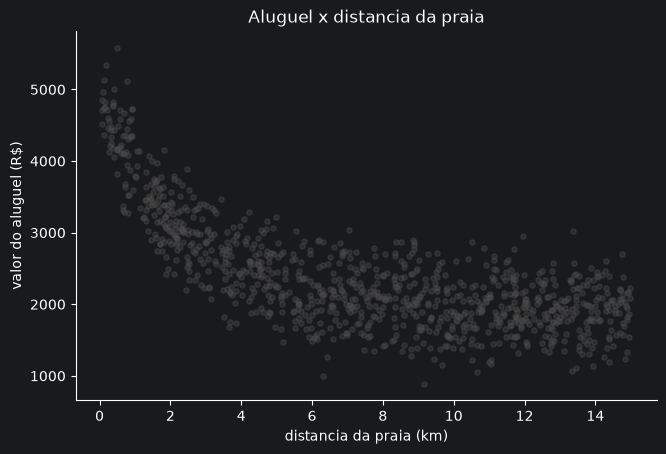

In [85]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(df["distancia_praia_km"], df["valor_aluguel"], s=14, alpha=0.4, color="#4c4c4c")
ax.set_xlabel("distancia da praia (km)")
ax.set_ylabel("valor do aluguel (R$)")
ax.set_title("Aluguel x distancia da praia")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

**Leitura:** a nuvem de pontos já deixa claro que a relação não é uma reta — o
aluguel despenca nos primeiros quilômetros e depois estabiliza. Ainda assim,
vale ajustar a reta e medir o quanto ela erra, para comparar depois com
regressão polinomial e SVR sobre a mesma variável.

### 3. Separando treino e teste

In [86]:
X = df[["distancia_praia_km"]].values
y = df["valor_aluguel"].values

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.30, random_state=SEMENTE
)
print(f"treino: {X_treino.shape[0]} imoveis   teste: {X_teste.shape[0]} imoveis")

treino: 700 imoveis   teste: 300 imoveis


### 4. Treinando a regressão linear simples

`y_previsto = b0 + b1 * distancia_praia_km`

In [87]:
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

print(f"b0 (intercepto)                       = {modelo.intercept_:.2f}")
print(f"b1 (coeficiente de distancia_praia_km) = {modelo.coef_[0]:.2f}")

b0 (intercepto)                       = 3406.21
b1 (coeficiente de distancia_praia_km) = -132.93


### 5. Avaliando no teste: MAE, RMSE e R²

In [88]:
y_pred = modelo.predict(X_teste)
residuos = y_teste - y_pred

mae = mean_absolute_error(y_teste, y_pred)
rmse = mean_squared_error(y_teste, y_pred) ** 0.5
r2 = r2_score(y_teste, y_pred)

print(f"MAE  = R$ {mae:.2f}")
print(f"RMSE = R$ {rmse:.2f}")
print(f"R^2  = {r2:.4f}")

MAE  = R$ 418.62
RMSE = R$ 530.56
R^2  = 0.4845


**Leitura:** compare este R² com os dos notebooks de regressão múltipla,
polinomial e SVR sobre a mesma base — é a régua para saber quanto cada
formulação diferente realmente ganha.

### 6. Visualizando a reta e os resíduos

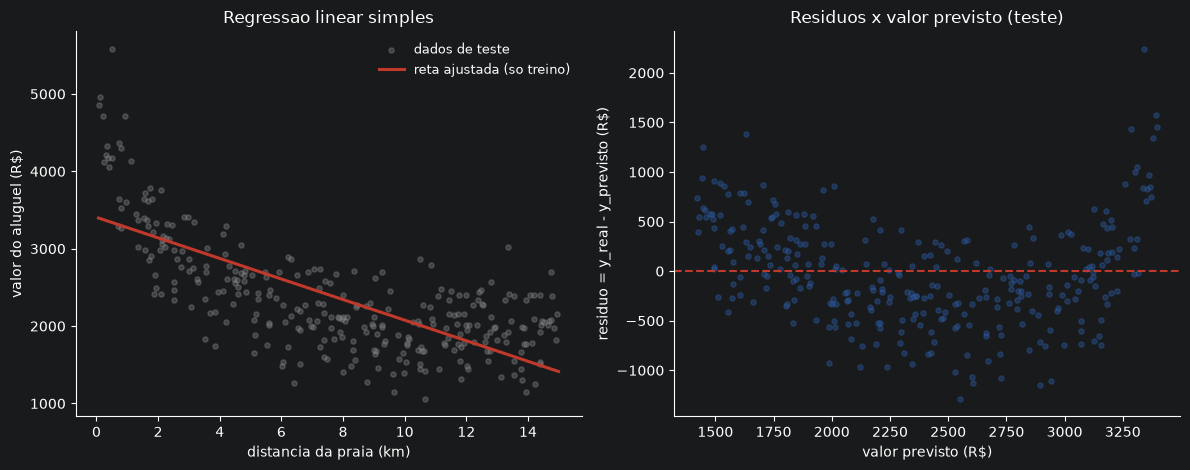

In [89]:
grade = np.linspace(df["distancia_praia_km"].min(), df["distancia_praia_km"].max(), 300).reshape(-1, 1)
y_grade = modelo.predict(grade)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].scatter(X_teste, y_teste, s=14, alpha=0.35, color="#8a8a8a", label="dados de teste")
axes[0].plot(grade, y_grade, color="#c0392b", linewidth=2.2, label="reta ajustada (so treino)")
axes[0].set_xlabel("distancia da praia (km)")
axes[0].set_ylabel("valor do aluguel (R$)")
axes[0].set_title("Regressao linear simples")
axes[0].legend(frameon=False, fontsize=9)

axes[1].scatter(y_pred, residuos, s=14, alpha=0.4, color="#2c5aa0")
axes[1].axhline(0, color="#c0392b", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("valor previsto (R$)")
axes[1].set_ylabel("residuo = y_real - y_previsto (R$)")
axes[1].set_title("Residuos x valor previsto (teste)")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

**Leitura:** o gráfico de resíduos mostra um padrão sistemático (não é uma
nuvem aleatória ao redor de zero) — sinal claro de que uma reta não é a
formulação certa aqui. É exatamente o problema que os notebooks de regressão
polinomial e SVR atacam, usando a mesma variável `distancia_praia_km`.

### 7. Pesquisar um valor

Digite uma distância até a praia (em km) e o modelo devolve o aluguel previsto.
Ao rodar este notebook no Jupyter, a célula abaixo pede a distância
interativamente; se não houver entrada disponível (por exemplo, ao executar o
notebook inteiro de uma vez), ela usa um valor de exemplo.

In [90]:
def prever_valor_aluguel(distancia_km):
    X_novo = np.array([[distancia_km]])
    return modelo.predict(X_novo)[0]


try:
    entrada = input("Digite a distancia da praia em km: ")
    distancia_pesquisada = float(entrada.replace(",", "."))
except Exception:
    distancia_pesquisada = 3.0
    print(f"(entrada interativa indisponivel - usando valor de exemplo: {distancia_pesquisada} km)")

valor_previsto = prever_valor_aluguel(distancia_pesquisada)
print(f"\nDistancia pesquisada: {distancia_pesquisada:.2f} km")
print(f"Valor de aluguel previsto (regressao linear simples): R$ {valor_previsto:.2f}")


Distancia pesquisada: 26.00 km
Valor de aluguel previsto (regressao linear simples): R$ -49.92


### O que guardar deste notebook

- Treino e teste foram separados **antes** de ajustar o modelo — MAE, RMSE e R²
  usam só o teste.
- O gráfico de resíduos com padrão sistemático é o sinal prático de que a
  relação não é linear — não adianta "melhorar" a reta, é preciso mudar a
  formulação.
- A função `prever_valor_aluguel` e a célula de pesquisa reaparecem, adaptadas,
  nos notebooks de regressão múltipla, polinomial e SVR — comparar os valores
  previstos para a mesma distância nos quatro notebooks é um bom exercício.